# Simple Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("E:\data\data_set\Salary_Data.csv")

In [3]:
df

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


# Spliting Data

In [4]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]
X,y

(    YearsExperience
 0               1.1
 1               1.3
 2               1.5
 3               2.0
 4               2.2
 5               2.9
 6               3.0
 7               3.2
 8               3.2
 9               3.7
 10              3.9
 11              4.0
 12              4.0
 13              4.1
 14              4.5
 15              4.9
 16              5.1
 17              5.3
 18              5.9
 19              6.0
 20              6.8
 21              7.1
 22              7.9
 23              8.2
 24              8.7
 25              9.0
 26              9.5
 27              9.6
 28             10.3
 29             10.5,
 0      39343
 1      46205
 2      37731
 3      43525
 4      39891
 5      56642
 6      60150
 7      54445
 8      64445
 9      57189
 10     63218
 11     55794
 12     56957
 13     57081
 14     61111
 15     67938
 16     66029
 17     83088
 18     81363
 19     93940
 20     91738
 21     98273
 22    101302
 23    113812
 24    10943

# Holdout Validation Method

- It is a type of model validation technique used in Machine Learning.
- Holdout validation is a model evaluation technique where the dataset is divided into training and testing subsets, the model is trained on the training set and evaluated on the test set.
- the ratio of dividing data 80:20,70:30,75:25

# Cross Validation
Cross Validation is a method used to evaluate a machine learning model by training and testing it multiple times on different splits of the dataset.


### Types of Cross Validation

- K-Fold Cross Validation (most common)

- Stratified K-Fold (for classification)

- Leave-One-Out Cross Validation (LOOCV)

- Repeated K-Fold

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# LinearRegression

- LinearRegression is a Supervised Machine Learning algorithm used for:

- 🎯 Predicting continuous numerical values

- It belongs to:
    
    📚 Regression Algorithms
    📊 Statistical Modeling

- its work only for 

# Mathematical Concept
    y=mx+c
- y = of target variable
- x = mean of indipendent variable
- c= intercept 
- m= slope (coefficient)

### formula for calculating the m
     - m= sum((x-xbar)(y-ybar))/sum(x-xbar)**2
     - c=y-mx

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
regressor=LinearRegression()

In [8]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### predict() is a method used to generate output predictions from a trained machine learning model.

- What Happens Internally?

After training, the model stores:

regressor.coef_ → slope (m)

regressor.intercept_ → intercept (c)

In [9]:
y_pred=regressor.predict(X_test)

In [10]:
comparision=pd.DataFrame({'Actual':y_test,'Prediction':y_pred})
comparision

,Actual,Prediction
27,112635,115573.622884
15,67938,71679.938782
23,113812,102498.908470
17,83088,75415.571471
8,64445,55803.499851
9,57189,60473.040713
28,122391,122110.980090
24,109431,107168.449332
12,56957,63274.765230


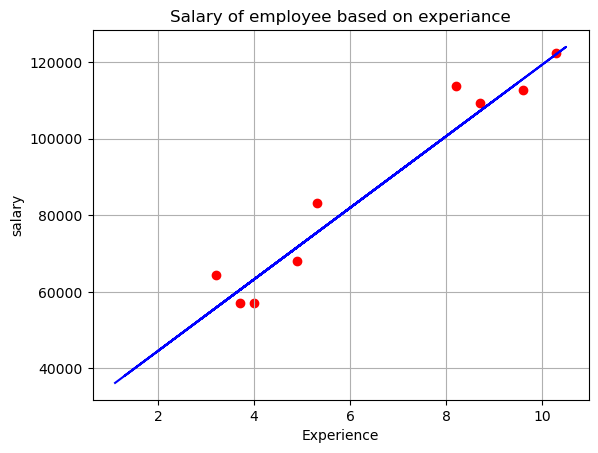

In [11]:
plt.scatter(X_test,y_test,color='Red')
plt.plot(X_train,regressor.predict(X_train),color='blue')
plt.title('Salary of employee based on experiance')
plt.xlabel('Experience')
plt.ylabel('salary')
plt.grid(True)
plt.show()

#### slope (coeficeint)
- How much the target (y) changes when one feature (x) increases by 1 unit.

In [12]:
# predict future
m_coef=regressor.coef_  # slope of the line (angle) of best fit line
m_coef

array([9339.08172382])

#### Intercept (intercept_)
👉 Meaning:

- The starting value of y when x = 0

- It is the point where the regression line crosses the Y-axis.

In [13]:
c_intercept=regressor.intercept_
c_intercept

np.float64(25918.438334893217)

In [14]:
20*m_coef+c_intercept

array([212700.0728112])

In [15]:
bias=regressor.score(X_train,y_train)
print(bias)

0.9574526669392872


In [16]:
variance=regressor.score(X_test,y_test)
variance

0.9414466227178214

In [17]:
m_coef*6+c_intercept

array([81952.92867778])

In [18]:
# creating a dataset of cgpa vs pacakage

In [19]:
np.random.seed(0)
package=pd.DataFrame({
    'cgpa': np.round(np.random.uniform(5, 10, 200), 2),
    'package in lpa':np.random.randint(2,15,200)
})
package

,cgpa,package in lpa
0,7.74,8
1,8.58,9
2,8.01,4
3,7.72,14
4,7.12,13
...,...,...
195,7.45,3
196,6.14,2
197,6.27,9
198,5.29,10


In [20]:
X=package.iloc[:,:-1]
y=package.iloc[:,-1]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [23]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred=regressor.predict(X_test)

In [25]:
comparision = pd.DataFrame({'Actual': y_test, 'Prediction': y_pred})
print(comparision) 



     Actual  Prediction
95       13    7.807656
15       14    7.830002
30       10    7.789033
158      10    7.755514
128       4    7.696854
..      ...         ...
97       12    7.845831
31       13    7.670318
12        2    7.718270
35        5    7.706631
119       8    7.689405

[66 rows x 2 columns]


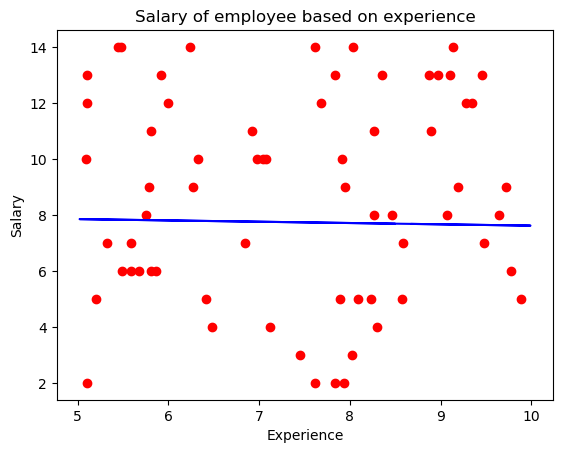

In [26]:
plt.scatter(X_test, y_test, color = 'Red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary of employee based on experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show() 


In [27]:
m_coef = regressor.coef_
print(m_coef)

c_intercept = regressor.intercept_
print(c_intercept)

y_20 = m_coef * 20 + c_intercept
print(y_20)


bias = regressor.score(X_train, y_train)
print(bias)

variance = regressor.score(X_test, y_test)
print(variance) 

[-0.04655518]
8.083262235484673
[7.15215861]
0.00029844360150788063
-0.060988196811909035


In [28]:
m_coef

array([-0.04655518])

# there is porblem in model i have to check it

# Placement Linear Regression Model

In [29]:
df=pd.read_csv("E:\data\data_set\placement.csv")

In [30]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in lpa) ')

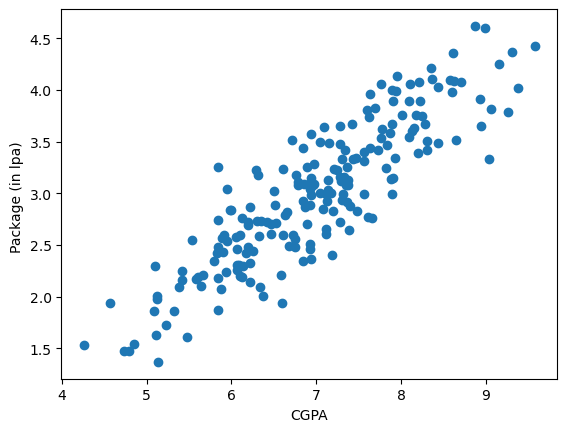

In [31]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (in lpa) ')

# spliting the data

In [32]:
X=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
 X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [36]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
X_test

,cgpa
95,6.63
15,7.25
30,7.36
158,5.95
128,7.93
115,8.35
69,7.30
170,6.22
174,7.32
45,7.87


In [38]:
y_test

95     2.79
15     3.23
30     3.26
158    3.04
128    3.34
115    4.21
69     2.94
170    2.87
174    2.99
45     3.58
66     1.63
182    2.08
165    4.08
78     2.21
186    3.47
177    3.64
56     2.74
152    3.08
82     2.17
68     2.99
124    2.31
16     2.35
148    3.40
93     3.08
65     3.81
60     2.19
84     1.53
67     2.89
125    3.16
132    2.48
9      3.51
18     2.98
55     3.39
75     3.28
150    2.73
104    3.74
135    2.60
137    3.13
164    3.82
76     3.15
Name: package, dtype: float64

In [39]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.78031348])

Text(0, 0.5, 'Package(in lpa)')

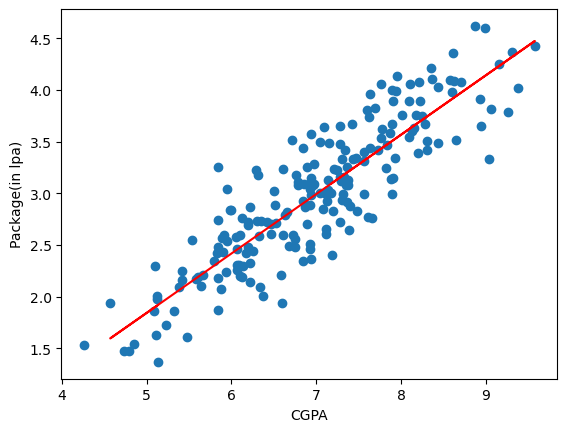

In [40]:

plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [41]:
m = lr.coef_
m

array([0.57425647])

In [42]:

b = lr.intercept_
b

np.float64(-1.02700693745421)

In [43]:

# y = mx + b

m * 8.58 + b

array([3.9001136])

In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

# Regression Model Building From Scratch

In [45]:
class MeraLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean())*(X_train[i] - X_train.mean()))
        
        self.m = num/den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)       
    
    def predict(self,X_test):
        
        print(X_test)
        
        return self.m * X_test + self.b

In [46]:
lr=MeraLR()

In [47]:
# lr.fit(X_train,y_train)

# Stastical Measures for Salary Model

In [48]:
sal=pd.read_csv("E:\data\data_set\Salary_Data.csv")

In [49]:
# mean
sal.mean()

YearsExperience        5.313333
Salary             76003.000000
dtype: float64

In [50]:
sal['Salary'].mean()

np.float64(76003.0)

In [51]:
# for experience
sal.mean()[0]

C:\Users\USER\AppData\Local\Temp\ipykernel_13636\3389668587.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sal.mean()[0]


np.float64(5.3133333333333335)

In [52]:
# Median
df.median()

cgpa       6.965
package    2.995
dtype: float64

In [53]:
# salary median
sal.median()[1]

C:\Users\USER\AppData\Local\Temp\ipykernel_13636\1743845135.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sal.median()[1]


np.float64(65237.0)

In [54]:
# mode
sal['Salary'].mode()

0      37731
1      39343
2      39891
3      43525
4      46205
5      54445
6      55794
7      56642
8      56957
9      57081
10     57189
11     60150
12     61111
13     63218
14     64445
15     66029
16     67938
17     81363
18     83088
19     91738
20     93940
21     98273
22    101302
23    105582
24    109431
25    112635
26    113812
27    116969
28    121872
29    122391
Name: Salary, dtype: int64

In [55]:
# variance
sal.var()

YearsExperience    8.053609e+00
Salary             7.515510e+08
dtype: float64

In [56]:
sal['Salary'].var()

751550960.4137931

In [57]:
# standard devaition
sal.std()

YearsExperience        2.837888
Salary             27414.429785
dtype: float64

In [58]:
sal['Salary'].std()

27414.4297845823

In [59]:
# Coefficient of variance (cv)
from scipy.stats import variation
variation(sal.values)

array([0.5251297 , 0.35463929])

In [60]:
variation(sal['Salary'])

np.float64(0.3546392938275572)

In [61]:
# correlation
sal.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [62]:
sal['Salary'].corr(sal['YearsExperience'])

np.float64(0.9782416184887598)

In [63]:
sal['YearsExperience'].corr(sal['Salary'])

np.float64(0.9782416184887599)

In [64]:
sal['Salary'].corr(sal['Salary'])

np.float64(1.0)

In [65]:
sal['YearsExperience'].corr(sal['YearsExperience'])

np.float64(0.9999999999999999)

In [66]:
# skewness
sal.skew()

YearsExperience    0.37956
Salary             0.35412
dtype: float64

In [67]:
sal.Salary.skew()

np.float64(0.35411967922959153)

In [68]:
# Standard Error
sal.sem()

YearsExperience       0.518125
Salary             5005.167198
dtype: float64

In [69]:
sal.Salary.sem()

np.float64(5005.167198052405)

In [70]:
# Z-score
import scipy.stats as stats
sal.apply(stats.zscore)

,YearsExperience,Salary
0,-1.510053,-1.360113
1,-1.438373,-1.105527
2,-1.366693,-1.419919
3,-1.187494,-1.204957
4,-1.115814,-1.339781
5,-0.864935,-0.718307
6,-0.829096,-0.588158
7,-0.757416,-0.799817
8,-0.757416,-0.428810
9,-0.578216,-0.698013


In [71]:
stats.zscore(sal.Salary)

array([-1.36011263, -1.10552744, -1.419919  , -1.20495739, -1.33978143,
       -0.71830716, -0.58815781, -0.79981746, -0.42881019, -0.69801306,
       -0.47433279, -0.74976858, -0.70662043, -0.70201994, -0.55250402,
       -0.29921736, -0.37004264,  0.26285865,  0.19885989,  0.66547573,
        0.58377993,  0.82623317,  0.93861127,  1.40274136,  1.24020308,
        1.09740238,  1.51986835,  1.3590738 ,  1.72102849,  1.70177321])

In [72]:
# degree of freedom
a=sal.shape[0]
b=sal.shape[1]
degree_of_freedom=a-b
degree_of_freedom

28

In [73]:
# Sum of Square Regression (SSR)
X=sal.iloc[:,:-1].values
y=sal.iloc[:,1].values

y_mean=np.mean(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,y_train)
y_predict=reg.predict(X_test)

SSR=np.sum((y_predict-y_mean)**2)
print(SSR)



6263152884.284124


In [74]:
# Sum of Square Error (SSE)
y=y[0:6]
SSE=np.sum((y-y_predict)**2)
print(SSE)

15274062883.943195


In [75]:
# Sum of Squares Total (SST)
mean_total=np.mean(sal.values)
SST=np.sum((sal.values-mean_total)**2)
print(SST)

108429703765.82735


In [76]:
# R-Square
r_square=SSR/SST
r_square

np.float64(0.057762335105244624)

In [77]:

from sklearn.feature_selection import VarianceThreshold
vt=VarianceThreshold(threshold=0)
### Make sure before fitting the dataframe , do not include output column
X=sal.drop('YearsExperience',axis=1) 
# X it self a data frame
vt.fit(X)
vt.variances_
vt.get_support()
cols=vt.get_feature_names_out()
X[cols]

,Salary
0,39343
1,46205
2,37731
3,43525
4,39891
5,56642
6,60150
7,54445
8,64445
9,57189


# House Prices Prediction linear Regression Model

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
house = pd.read_csv(r"E:\data\data_set\House_data.csv")

In [80]:
house.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [91]:
space=house['sqft_living']
price=house['price']

x = np.array(space).reshape(-1, 1)
y = np.array(price)


In [92]:
# Spliting the data into train and test
from sklearn.model_selection import train_test_split
# from sklearn.model_selection import train_test_split 
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=1/3, random_state=0)

In [99]:
from sklearn.linear_model import LinearRegression 
regressor = LinearRegression()
regressor.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
# predicting the price
pred=regressor.predict(X_test)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [96]:
pred

array([ -58.49064669, -209.32943333,  -58.9561985 , ...,  -78.97492635,
        -45.9207478 ,  -40.33412607], shape=(7205,))

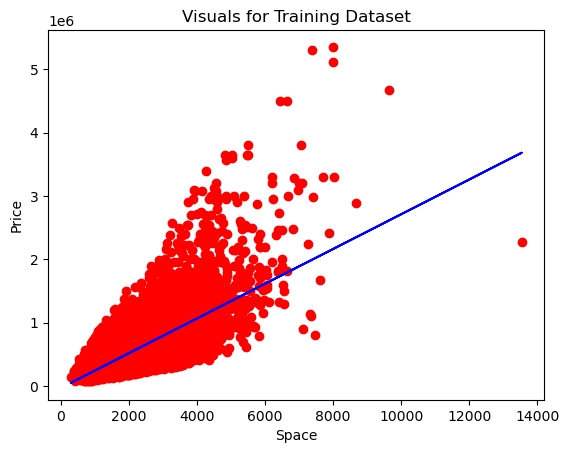

In [101]:
#Predicting the prices
pred = regressor.predict(xtest)

#Visualizing the training Test Results 
plt.scatter(xtrain, ytrain, color= 'red')
plt.plot(xtrain, regressor.predict(xtrain), color = 'blue')
plt.title ("Visuals for Training Dataset")
plt.xlabel("Space")
plt.ylabel("Price")
plt.show()

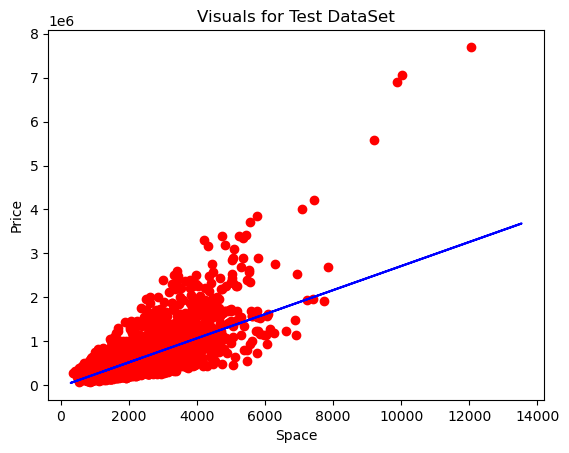

In [102]:
#Visualizing the Test Results 
plt.scatter(xtest, ytest, color= 'red')
plt.plot(xtrain, regressor.predict(xtrain), color = 'blue')
plt.title("Visuals for Test DataSet")
plt.xlabel("Space")
plt.ylabel("Price")
plt.show()


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory


# Any results you write to the current directory are saved as output.

#Import Libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 



#Importing DataSet 
dataset = pd.read_csv(r"E:\data\data_set\House_data.csv")
space=dataset['sqft_living']
price=dataset['price']

x = np.array(space).reshape(-1, 1)
y = np.array(price)

#Splitting the data into Train and Test
from sklearn.model_selection import train_test_split 
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=1/3, random_state=0)


#Fitting simple linear regression to the Training Set
from sklearn.linear_model import LinearRegression 
regressor = LinearRegression()
regressor.fit(xtrain, ytrain)

#Predicting the prices
pred = regressor.predict(xtest)

#Visualizing the training Test Results 
plt.scatter(xtrain, ytrain, color= 'red')
plt.plot(xtrain, regressor.predict(xtrain), color = 'blue')
plt.title ("Visuals for Training Dataset")
plt.xlabel("Space")
plt.ylabel("Price")
plt.show()

#Visualizing the Test Results 
plt.scatter(xtest, ytest, color= 'red')
plt.plot(xtrain, regressor.predict(xtrain), color = 'blue')
plt.title("Visuals for Test DataSet")
plt.xlabel("Space")
plt.ylabel("Price")
plt.show()


In [ ]:
# Electricity bill model

In [103]:
bill=pd.read_csv("E:\data\data_set\electricity_bill_200_records.csv")

In [104]:
bill.head()

,Units_Consumed,Price_Rs
0,152,911
1,485,2919
2,398,2378
3,320,1927
4,156,940


In [109]:
X=bill.iloc[:,:-1].values
y=bill.iloc[:,-1].values

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [112]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

In [113]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [121]:
pred=reg.predict(X_test)

In [122]:
reg.coef_

array([6.00860834])

In [123]:
reg.intercept_

np.float64(-1.339788202119962)